# **SpongeWorks**


## Setup 

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import rioxarray
import hvplot.xarray
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.geometry import box
import contextily as ctx
import openeo
from pyproj import Transformer
import geoviews as gv
import hvplot.pandas
import geoviews.tile_sources as gts
import seaborn as sns
import panel as pn
from glob import glob
from matplotlib.cm import viridis, plasma, RdYlBu_r
from bokeh.models import ColumnDataSource, TapTool, CustomJS
from bokeh.plotting import figure
import socket
import matplotlib.colors as mcolors
from bokeh.plotting import figure, show, output_notebook
output_notebook()
import warnings
warnings.filterwarnings("ignore")

Loading BokehJS ...

In [2]:
def assign_lon_lat_to_xarray(data, lon, lat):
    """
    Assigns longitude and latitude values to xarray's x and y coordinates.

    Args:
        lai_data (xr.Dataset): The xarray Dataset.
        lon (np.ndarray): 2D array of longitude values.
        lat (np.ndarray): 2D array of latitude values.

    Returns:
        xr.Dataset: The xarray Dataset with updated coordinates.
    """

    # Ensure lon and lat match the shape of the x and y dimensions.
    if lon.shape != (data.y.size, data.x.size) or lat.shape != (data.y.size, data.x.size):
        raise ValueError("lon and lat arrays do not match the shape of xarray's x and y dimensions.")

    # Extract 1D arrays to assign to x and y coordinates.
    new_lon_x = lon[0, :]  # First row of lon (representing x)
    new_lat_y = lat[:, 0]  # First column of lat (representing y)

    # Assign the new coordinates:
    data = data.assign_coords({"x": new_lon_x, "y": new_lat_y})

    return data

## Area(s) of interest 
---- 
This section establishes the spatial boundaries and field locations for our analysis. We begin by loading the **area of interest (AOI)** boundary from a GeoJSON file, which defines the broader study region. From this AOI, we extract the **bounding box coordinates** (West, South, East, North) that will be used to query satellite data from the appropriate geographic extent.

Additionally, we load the **field boundaries** (`MuW.geojson`) that define the two specific agricultural fields we'll monitor throughout the analysis. These field polygons will be used to:

- Clip satellite imagery to field-specific extents
- Calculate spatially-averaged statistics within each field
- Compare water content dynamics between the two sites

The AOI provides the broader context while the individual field boundaries enable precise, field-scale analysis of soil moisture and water content indicators from both SAR and optical satellite data.

In [3]:
## Broader area of Inteest
site = 'MuW'  # Options: 'wallingford', 'MuW'
aoi = gpd.read_file(f'/Users/vm/Desktop/dir/spongeworks/data/{site}.geojson')
# Set CRS for the area of interest
aoi = aoi.set_crs("EPSG:4326", allow_override=True)
## Bounding box
W, S, E, N = aoi.total_bounds

<Axes: >

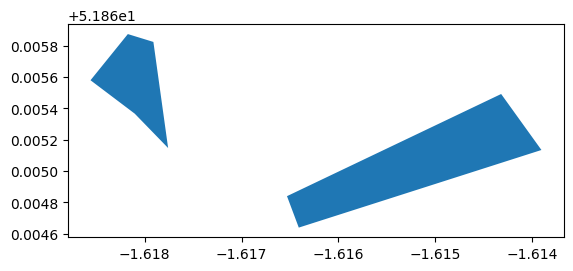

In [4]:
aoi.plot()

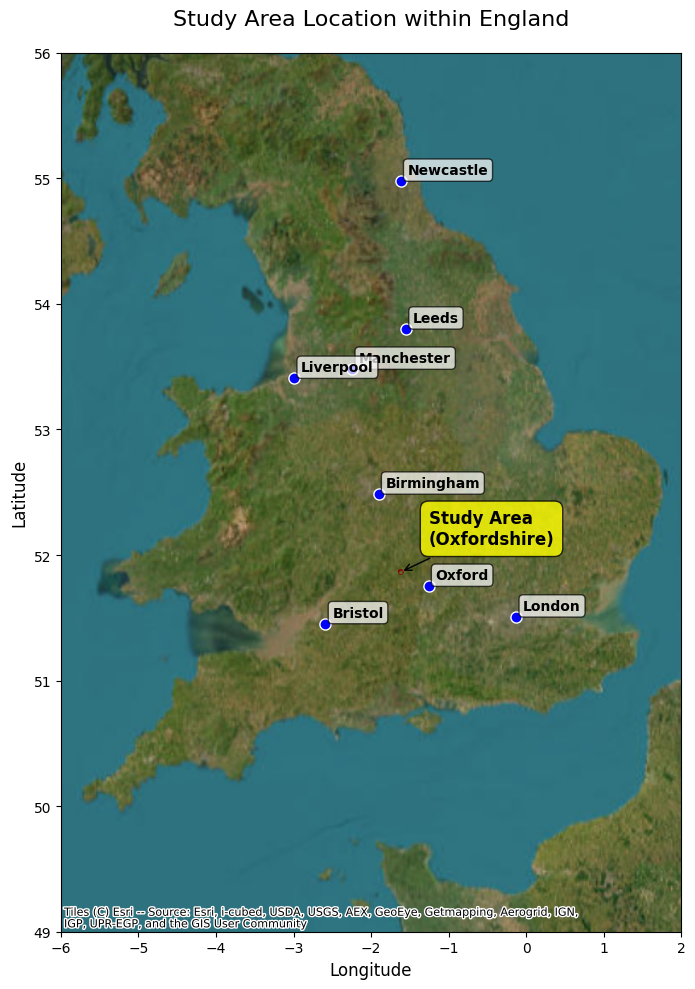

In [5]:
# Create a figure showing AOI location in England context
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Create a larger bounding box to show England context
england_bounds = [-6, 49, 2, 56]  # Rough bounds for England and surrounding areas
england_box = gpd.GeoDataFrame([1], geometry=[box(*england_bounds)], crs="EPSG:4326")

# Plot England context area (invisible, just for extent)
england_box.plot(ax=ax, facecolor='none', edgecolor='none')

# Add satellite basemap for England using EPSG:4326
ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldImagery, zoom=6)

# Plot AOI as a prominent red dot/area
aoi.plot(ax=ax, facecolor='red', edgecolor='darkred', linewidth=4, alpha=0.9, markersize=100)

# Set extent to show England and surrounding areas
ax.set_xlim(england_bounds[0], england_bounds[2])
ax.set_ylim(england_bounds[1], england_bounds[3])

# Add major cities for context
cities = {
    'London': (-0.1276, 51.5074),
    'Birmingham': (-1.9026, 52.4862),
    'Manchester': (-2.2426, 53.4808),
    'Liverpool': (-2.9916, 53.4084),
    'Leeds': (-1.5491, 53.8008),
    'Newcastle': (-1.6178, 54.9783),
    'Bristol': (-2.5879, 51.4545),
    'Oxford': (-1.2581, 51.7520)
}

for city, (lon, lat) in cities.items():
    ax.plot(lon, lat, 'ko', markersize=8, markerfacecolor='blue', markeredgecolor='white', markeredgewidth=1)
    ax.annotate(city, (lon, lat), xytext=(5, 5), textcoords='offset points', 
                fontsize=10, fontweight='bold', color='black',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

# Add title and labels
ax.set_title('Study Area Location within England', fontsize=16, pad=20)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)

# Add text annotation for the AOI
aoi_center = aoi.geometry.centroid.iloc[0]
ax.annotate('Study Area\n(Oxfordshire)', 
            xy=(aoi_center.x, aoi_center.y), 
            xytext=(20, 20), 
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.8),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
            fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [6]:
## Fields of interest within the AOI
MuW = gpd.read_file("/Users/vm/Desktop/dir/spongeworks/data/MuW.geojson")

## Source and process met, SAR and optical data
------
This section focuses on sourcing and processing the necessary datasets for our analysis, including meteorological data, Sentinel-1 SAR imagery, and Sentinel-2 optical imagery.

### ERA5 Met Data

In [7]:
# ## Produce met_DF dataset
# folders_met = []
# for file in glob("/Users/vm/Documents/Scripts and Data/data/ERA5/*") : 
# 	folders_met.append(file)
# folders_met.sort()

# siteLat = aoi.geometry.centroid.y[0] #.centroid.y.iloc[0]
# siteLon = aoi.geometry.centroid.x[0] #.centroid.x.iloc[0]

# met_DF = pd.DataFrame(columns=['date','minT','maxT','srad','vpd','wind','photopd','21d_vpd','21d_minT','21d_photopd','prec'])

# for ii in range(len(folders_met)):

# 	ds1 = xr.open_dataset(f"{folders_met[ii]}/data_stream-oper_stepType-instant.nc",engine='netcdf4')
# 	ds2 = xr.open_dataset(f"{folders_met[ii]}/data_stream-oper_stepType-accum.nc",engine='netcdf4')
# 	dsloc1 = ds1.sel(longitude=float(siteLon),latitude=float(siteLat),method='nearest') 
# 	dsloc2 = ds2.sel(longitude=float(siteLon),latitude=float(siteLat),method='nearest') 
# 	df1 = dsloc1.to_dataframe()
# 	df2 = dsloc2.to_dataframe()
# 	## unit conversion
# 	df1.t2m = df1.t2m - 273.15
# 	df1.d2m = df1.d2m - 273.15
# 	## relative humidity (http:/andrew.rsmas.miami.edu/bmcnoldy/Humidity.html)
# 	df1['RH'] = 100*(np.exp((17.625*df1.d2m)/(243.04+df1.d2m))/np.exp((17.625*df1.t2m)/(243.04+df1.t2m))) 
# 	## vapor pressure deficit (http:/cronklab.wikidot.com/calculation-of-vapour-pressure-deficit)
# 	df1['VPD'] = (1-(df1.RH/100)) * (610.7*10**(7.5*df1.t2m/(237.3+df1.t2m)))
# 	df1['windspeed'] = (df1.u10**2 + df1.v10**2)**0.5

# 	df1 = df1.reset_index()
# 	df1.index = pd.to_datetime(df1.valid_time)
# 	df1 = df1.drop(columns=['expver'])
# 	df2 = df2.reset_index()
# 	df2.index = pd.to_datetime(df2.valid_time)
# 	df2 = df2.drop(columns=['expver'])

# 	for t in range(len(df1.resample('D').mean())):
# 			met_DF = met_DF._append({'date' : (df1.resample('D').mean()).index[t],
# 									'doy'  : (df1.resample('D').mean()).index.dayofyear[t],
# 									'avgT' : (df1.t2m.resample('D',label='left').mean()).iloc[t],
# 									'prec' : (df2.tp.resample('D',label='left').mean()).iloc[t] * 1000, # / 3600 , # m to mm.s-1 i.e. kg.rain.m-2.s-1
# 									'wind' : (df1.windspeed.resample('D',label='left').mean()).iloc[t],
# 									'vpd'  : (df1.VPD.resample('D',label='left').mean()).iloc[t],
# 									},ignore_index=True)



### Sentinel-1 SAR and Sentinel-2 Optical Data

In [8]:
# # Connect to the back-end and authenticate. 
# connection = openeo.connect("openeofed.dataspace.copernicus.eu")
# connection.authenticate_oidc()

# # Set the period of interest 
# poi = ["2017-01-01", "2024-12-31"]

# # Initialize our datacube object with the area of interest 
# # and the time range of interest using Sentinel 2 data.
# datacube = connection.load_collection(
#     "SENTINEL2_L2A",
#     spatial_extent={"west": W, "south": S, "east": E, "north": N}, # "crs": "EPSG:4326"
#     temporal_extent=poi,
#     bands=["B03", "B08", "SCL"],
#     max_cloud_cover=30,
# )

# # From this data cube, we can now select the individual bands and rescale the digital number values to physical reflectances:
# B03 = datacube.band("B03") * 0.0001
# B08 = datacube.band("B08") * 0.0001
# SCL = datacube.band("SCL") # Scene classification layer

# # Cloud masking using the SCL band
# cloud_mask = ((SCL == 8) | (SCL == 9) | (SCL == 3)) * 1.0

# # Apply the cloud mask
# masked_cube = datacube.mask(cloud_mask)

# # Recalculate the bands after masking
# B03_masked = masked_cube.band("B03") * 0.0001
# B08_masked = masked_cube.band("B08") * 0.0001

# # Calculate sar
# sar_cube = (B03_masked - B08_masked) / (B03_masked + B08_masked)

# sar_cube.download('/Users/vm/Desktop/dir/spongeworks/data/wallingford/ndwi_2017_2024.nc', format="NetCDF")

# # Query the Sentinel-1 data collection for the same period
# datacube = connection.load_collection(
#     "SENTINEL1_GRD",
#     spatial_extent={"west": W, "south": S, "east": E, "north": N}, # "crs": "EPSG:4326"
#     temporal_extent=poi,
#     bands=["VV", "VH"]
# )

# # Calculate backscatter using the datacube
# s1_scatter = datacube.sar_backscatter(coefficient="sigma0-ellipsoid", elevation_model="COPERNICUS_30", noise_removal=True)
# s1bs = s1_scatter.apply(lambda x: 10 * x.log(base=10))

# # Save to netcdf
# s1bs.download("/Users/vm/Desktop/dir/spongeworks/data/wallingford/sar_bs_2017_2024.nc")


### Copernicus Land Monitoring Service - Surface Soil Moisture (SSM) - 1km resolution

In [ ]:
## Broader area of Inteest
site = 'MuW'  # Options: 'wallingford', 'MuW'
aoi = gpd.read_file(f'/Users/vm/Desktop/dir/spongeworks/data/{site}.geojson') 
# Set CRS for the area of interest
aoi = aoi.set_crs("EPSG:4326", allow_override=True)
# Build a 10 km x 10 km rectangle centered on the AOI (in a metric CRS), then convert back to EPSG:4326
aoi_metric = aoi.to_crs(aoi.estimate_utm_crs())
minx, miny, maxx, maxy = aoi_metric.total_bounds
cx, cy = (minx + maxx) / 2, (miny + maxy) / 2
half_size_m = 5000  # 5 km each side from center

aoi = gpd.GeoDataFrame(
    geometry=[box(cx - half_size_m, cy - half_size_m, cx + half_size_m, cy + half_size_m)],
    crs=aoi_metric.crs
).to_crs("EPSG:4326")
## Bounding box
W, S, E, N = aoi.total_bounds

# Connect to the back-end and authenticate. 
connection = openeo.connect("openeofed.dataspace.copernicus.eu")
connection.authenticate_oidc()

# Set the period of interest 
poi = ["2017-01-01", "2025-06-30"]

# Initialize our datacube object with the area of interest 
# and the time range of interest using Sentinel 2 data.
datacube = connection.load_collection(
    "CGLS_SSM_V1_EUROPE",
    spatial_extent={"west": W, "south": S, "east": E, "north": N}, # "crs": "EPSG:4326"
    temporal_extent=poi,
    bands=["ssm"])

job = datacube.create_job(title="ssm-wallingford")
job.start_and_wait()
job.get_results().download_files("/Users/vm/Desktop/dir/spongeworks/data/wallingford/ssm_2017_2025/")

tif_files = sorted(glob("/Users/vm/Desktop/dir/spongeworks/data/wallingford/ssm_2017_2025/*.tif"))

if not tif_files : raise FileNotFoundError("No .tif files found in the target folder.")

# Read each tif as DataArray, drop singleton band dimension if present
ssm_list = [rioxarray.open_rasterio(fp).squeeze(drop=True) for fp in tif_files]

# Extract date from filename using characters between -15 and -5
# Example: "openEO_2017-01-01Z.tif" -> "2017-01-01"
date_strs = [fp.split("/")[-1][-15:-5] for fp in tif_files]
time_values = pd.to_datetime(date_strs, format="%Y-%m-%d", errors="coerce")

if time_values.isna().any():
    bad = [tif_files[i] for i, v in enumerate(time_values.isna()) if v][:5]
    raise ValueError(f"Could not parse dates from some filenames. Examples: {bad}")

# Concatenate along time
ssm_merged = xr.concat(ssm_list, dim="time").assign_coords(time=time_values)

# Convert to Dataset and save
ssm_ds = ssm_merged.to_dataset(name="ssm")
out_nc = "/Users/vm/Desktop/dir/spongeworks/data/wallingford/ssm_2017_2025.nc"
ssm_ds.to_netcdf(out_nc)

Authenticated using refresh token.
0:00:00 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': send 'start'
0:00:12 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:00:17 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:00:23 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:00:31 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:00:41 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:00:54 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:01:09 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:01:29 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:01:53 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:02:23 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (progress 0%)
0:03:00 Job 'terrascope-j-2603091621244ccd9766e86e4c70b3df': queued (pr

### Transform data 

In [ ]:
# ndwi_all = xr.open_dataset(f'/Users/vm/Desktop/dir/spongeworks/data/{site}/ndwi_2017_2024.nc')
# transformer_ndwi = Transformer.from_crs(ndwi_all.crs.attrs['crs_wkt'], "epsg:4326", always_xy=True)
# xv_ndwi, yv_ndwi = np.meshgrid(ndwi_all.x, ndwi_all.y)
# lon_ndwi, lat_ndwi = transformer_ndwi.transform(xv_ndwi, yv_ndwi)
# ndwi_all = assign_lon_lat_to_xarray(ndwi_all, lon_ndwi, lat_ndwi)
# ndwi_all = ndwi_all.rename({'var': 'NDWI'})
# ndwi_all.crs.attrs['crs_wkt'] = "epsg:4326"
# ndwi_all.to_netcdf(f"/Users/vm/Desktop/dir/spongeworks/data/{site}/ndwi.nc")

# sar_all = xr.open_dataset(f'/Users/vm/Desktop/dir/spongeworks/data/{site}/sar_bs_2017_2024.nc')
# transformer_sar = Transformer.from_crs(sar_all.crs.attrs['crs_wkt'], "epsg:4326", always_xy=True)
# xv_sar, yv_sar = np.meshgrid(sar_all.x, sar_all.y)
# lon_sar, lat_sar = transformer_sar.transform(xv_sar, yv_sar)
# sar_all = assign_lon_lat_to_xarray(sar_all, lon_sar, lat_sar)
# sar_all.crs.attrs['crs_wkt'] = "epsg:4326"
# sar_all.to_netcdf(f"/Users/vm/Desktop/dir/spongeworks/data/{site}/sar_bs.nc")

## Data Analysis and Visualization
------ 
This section covers the analysis and visualization of the processed datasets. We will generate time series plots, explore relationships between different water content indicators, and create interactive visualizations for data exploration.

In [10]:
## Load data
ndwi_all = xr.open_dataset(f"/Users/vm/Desktop/dir/spongeworks/data/{site}/ndwi.nc", engine="netcdf4")
sar_all = xr.open_dataset(f"/Users/vm/Desktop/dir/spongeworks/data/{site}/sar_bs.nc", engine="netcdf4")
ndwi_aligned = ndwi_all.interp(x=sar_all.x, y=sar_all.y, method='nearest')

# Combine datasets using xarray merge, keeping all timestamps from both datasets
combined_ds = xr.merge([
    ndwi_aligned[['NDWI']],
    sar_all[['VV','VH']]
], join='outer')

# Calculate VV/VH ratio
combined_ds['VVVH_ratio'] = combined_ds['VV'] / combined_ds['VH']
# Create water detection masks using SAR backscatter thresholds
combined_ds['Water_mask'] = ((combined_ds['VV'] < -18) | (combined_ds['VH'] < -22)).astype(int)  # Open water detection using VV , Flooded vegetation using VH
combined_ds = combined_ds.rio.write_crs("EPSG:4326", inplace=False) # Ensure SAR data has CRS set before clipping

In [25]:
from shapely.geometry import box

# Load the KML file as a GeoDataFrame
littlestock_brook = gpd.read_file("/Users/vm/Desktop/dir/spongeworks/data/Littlestock_Brook_digitalrivernetwork_50k_gb_ukceh.kml")
littlestock_brook = littlestock_brook.set_crs("EPSG:4326", allow_override=True)

# Clip littlestock_brook to the extent of ndwi_all
# Get the bounds of ndwi_all as a shapely box
ndwi_bounds = ndwi_all.rio.bounds()
ndwi_box = box(*ndwi_bounds)
sar_bounds = sar_all.rio.bounds()
ndwi_box = box(*sar_bounds)

# Crop (clip) the vector data to the raster extent
littlestock_brook = gpd.clip(littlestock_brook, ndwi_box)
# Flood proxy 
flood_proxy = gpd.read_file("/Users/vm/Desktop/dir/spongeworks/data/Littlestock_Brook_flooding_proxy_field.kml")
flood_proxy = flood_proxy.set_crs("EPSG:4326", allow_override=True)
## Fields of interest within the AOI
MuW = gpd.read_file("/Users/vm/Desktop/dir/spongeworks/data/MuW.geojson")
bunds = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/bunds.geojson')

In [ ]:
# Load the SSM (Surface Soil Moisture) dataset
ssm_ds = xr.open_dataset("/Users/vm/Desktop/dir/spongeworks/data/wallingford/ssm_2017_2025.nc")
# Get centroid of the first AOI polygon
aoi_centroid = aoi.iloc[0].geometry.centroid
centroid_x, centroid_y = aoi_centroid.x, aoi_centroid.y

# Find the closest pixel in ssm_ds to the centroid
x_idx = np.abs(ssm_ds.x.values - centroid_x).argmin()
y_idx = np.abs(ssm_ds.y.values - centroid_y).argmin()

closest_pixel = dict(x=ssm_ds.x.values[x_idx], y=ssm_ds.y.values[y_idx])
print("Closest pixel coordinates:", closest_pixel)

# Extract the SSM time series at the closest pixel
ssm_timeseries = ssm_ds['ssm'][:, y_idx, x_idx].to_series()
ssm_timeseries.plot()


In [26]:
import panel as pn
import geoviews as gv

pn.extension()

# Ensure 'Longitude' and 'Latitude' columns exist for plotting
bunds['Longitude'] = bunds.geometry.x
bunds['Latitude'] = bunds.geometry.y

# Create the Points plot with 'name' as a value dimension
bunds_plot = gv.Points(
    bunds,
    kdims=['Longitude', 'Latitude'],
    vdims=['name']
).opts(
    size=4,
    color='red',
    tools=['hover'],
    nonselection_alpha=0.3,
    title='Bunds'
)

# Create a list of available dates from ndwi_all.t
available_dates = pd.to_datetime(ndwi_all.t.values)
date_picker = pn.widgets.DatePicker(
    name='Select Date',
    value=available_dates[0].date(),
    start=available_dates[0].date(),
    end=available_dates[-1].date()
)

# Use an integer index for navigation
idx = pn.widgets.IntInput(name='Index', value=0, start=0, end=len(available_dates)-1, step=1, visible=False)

def update_index_from_date(event):
    selected_date = pd.to_datetime(date_picker.value)
    time_diffs = np.abs(available_dates - selected_date)
    closest_idx = int(time_diffs.argmin())
    idx.value = closest_idx

def update_date_from_index(event):
    date_picker.value = available_dates[idx.value].date()

date_picker.param.watch(update_index_from_date, 'value')
idx.param.watch(update_date_from_index, 'value')

def prev_event(event):
    if idx.value > 0:
        idx.value -= 1

def next_event(event):
    if idx.value < len(available_dates) - 1:
        idx.value += 1

prev_button = pn.widgets.Button(name='Previous', button_type='primary')
next_button = pn.widgets.Button(name='Next', button_type='primary')
prev_button.on_click(prev_event)
next_button.on_click(next_event)

def ndwi_map_for_date(idx_val):
    t_val = ndwi_all.t.values[idx_val]
    img = ndwi_all.sel(t=t_val)['NDWI']
    hv_img = img.hvplot.image(
        x='x', y='y', cmap='Blues', clim=(-0.8, 1),
        frame_width=500, frame_height=400, title=f'NDWI {str(pd.to_datetime(t_val).date())}', geo=True
    )
    overlay = (
        hv_img
        * bunds_plot.opts(global_extent=False)
        * flood_proxy.hvplot(geo=True, color='white', alpha=0.33, line_width=2, label='Flood Proxy').opts(global_extent=False)
        * littlestock_brook.hvplot(geo=True, color='blue', line_width=2, label='Waterways').opts(global_extent=False)
    )
    return overlay

interactive_plot = pn.bind(ndwi_map_for_date, idx)

pn.Column(
    pn.Row(prev_button, next_button, date_picker),
    interactive_plot
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'36daa7da-08da-4eda-9dbb-54bf7267d884': {'version…

In [ ]:
pn.extension()

# Create a list of available dates from combined_ds.t
available_dates = pd.to_datetime(combined_ds.t.values)
date_picker = pn.widgets.DatePicker(
    name='Select Date',
    value=available_dates[0].date(),
    start=available_dates[0].date(),
    end=available_dates[-1].date()
)

# Use an integer index for navigation
idx = pn.widgets.IntInput(name='Index', value=0, start=0, end=len(available_dates)-1, step=1, visible=False)

def update_index_from_date(event):
    selected_date = pd.to_datetime(date_picker.value)
    time_diffs = np.abs(available_dates - selected_date)
    closest_idx = int(time_diffs.argmin())
    idx.value = closest_idx

def update_date_from_index(event):
    date_picker.value = available_dates[idx.value].date()

date_picker.param.watch(update_index_from_date, 'value')
idx.param.watch(update_date_from_index, 'value')

def prev_event(event):
    if idx.value > 0:
        idx.value -= 1

def next_event(event):
    if idx.value < len(available_dates) - 1:
        idx.value += 1

prev_button = pn.widgets.Button(name='Previous', button_type='primary')
next_button = pn.widgets.Button(name='Next', button_type='primary')
prev_button.on_click(prev_event)
next_button.on_click(next_event)

def sar_map_for_date(idx_val):
    t_val = combined_ds.t.values[idx_val]
    img = combined_ds.sel(t=t_val)['VH']
    hv_img = img.hvplot.image(
        x='x', y='y', cmap='viridis', clim=(-27, -5),
        frame_width=500, frame_height=400, title=f'VH {str(pd.to_datetime(t_val).date())}', geo=True
    )
    overlay = (
        hv_img
        * bunds_plot.opts(global_extent=False)
        * flood_proxy.hvplot(geo=True, color='white', alpha=0.33, line_width=2, label='Flood Proxy').opts(global_extent=False)
        * littlestock_brook.hvplot(geo=True, color='blue', line_width=2, label='Waterways').opts(global_extent=False)
    )
    return overlay

interactive_plot = pn.bind(sar_map_for_date, idx)

pn.Column(
    pn.Row(prev_button, next_button, date_picker),
    interactive_plot
)


In [ ]:
from shapely.geometry import Point

bunds = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/bunds.geojson')
bunds = bunds[bunds['name'].str.lower().str.contains('bund')]
bund_clipped_dfs = []

for _, row in bunds.iterrows():
    bund_name = row['name']
    centroid = row.geometry
    # Create a 50m buffer (circle) around the centroid, assuming CRS is EPSG:4326, so buffer in degrees
    # Convert 50 meters to degrees (approx): 1 deg lat ~ 111,320 m, so 50m ~ 0.00045 deg
    buffer_radius_deg = 50 / 111320
    circle = centroid.buffer(buffer_radius_deg)
    # Clip combined_ds to this circle
    clipped = combined_ds.rio.clip([circle], drop=True, invert=False)
    # Convert to dataframe, add bund name
    df = clipped.to_dataframe().reset_index()
    df['bund_name'] = bund_name
    bund_clipped_dfs.append(df)

# Concatenate all bund dataframes
bunds_combined_df = pd.concat(bund_clipped_dfs, ignore_index=True)

# Rename 'Bund -5' to 'Bund-5' in all relevant data structures

# 1. In bund_options list
bund_options = ['Bund-5' if b == 'Bund -5' else b for b in bund_options]

# 2. In bunds_combined_df and bunds_combined_weekly DataFrames
bunds_combined_df['bund_name'] = bunds_combined_df['bund_name'].replace('Bund -5', 'Bund-5')
bunds_combined_weekly['bund_name'] = bunds_combined_weekly['bund_name'].replace('Bund -5', 'Bund-5')

# 3. In bunds GeoDataFrame
bunds['name'] = bunds['name'].replace('Bund -5', 'Bund-5')

# weekly aggregation 
# bunds_combined_weekly = bunds_combined_df.groupby(['bund_name', pd.Grouper(key='t', freq='W')]).mean(numeric_only=True).reset_index()


In [ ]:
pn.extension('holoviews')

# Get unique bund names and variable options from the DataFrame
bund_options = sorted(bunds_combined_df['bund_name'].unique())
var_options = ['NDWI', 'VV', 'VH', 'VVVH_ratio', 'Water_mask']

bund_selector = pn.widgets.Select(name='Bund', options=bund_options, value=bund_options[0])
var_selector = pn.widgets.Select(name='Variable', options=var_options, value='NDWI')

def plot_bund_variable(bund, var):
    df = bunds_combined_df[bunds_combined_df['bund_name'] == bund]
    times = df['t'].values
    yvals = df[var].values
    # Remove NaNs for plotting
    mask = ~np.isnan(yvals)
    times = times[mask]
    yvals = yvals[mask]
    if len(times) == 0:
        return hv.Text(0, 0, f"No data for {var}").opts(width=400, height=300)
    scatter = hv.Scatter((times, yvals), 'Date', var).opts(
        width=600, height=350, color='navy', size=6, tools=['hover'],
        title=f"{var} weekly mean for {bund}", marker='o'
    )
    return scatter

interactive_plot = pn.bind(plot_bund_variable, bund_selector, var_selector)
pn.Column(
    pn.Row(bund_selector, var_selector),
    interactive_plot
)


In [ ]:
# Define colormaps
viridis_cmap = viridis
viridis_r_cmap = viridis.reversed()
plasma_cmap = plasma
rdylbu_cmap = RdYlBu_r

# Clip to the MuW area (using the second geometry from the aoi dataframe)
# MuW.iloc[1] corresponds to the user-given area
field_geometry = flood_proxy.iloc[0].geometry # aoi.iloc[2].geometry  # Using aoi instead of MuW as it's the available variable

# Clip the combined dataset to the selected field area
combined_field_data = combined_ds.rio.clip([field_geometry], drop=True, invert=False)

# Resample to weekly averages for better visualization performance
combined_field_data = combined_field_data.resample(t='W').mean()

# Create interactive visualization with variable selection
# Create basemap and print selected variable info
basemap = gv.tile_sources.EsriImagery().opts(width=400, height=550)

# Use weekly resampled dates for the slider
dates = combined_field_data.t.values
date_labels = [np.datetime_as_string(d, unit='D') for d in dates]

# Use an integer index for navigation
idx = pn.widgets.IntInput(name='Index', value=0, start=0, end=len(dates)-1, step=1, visible=False)

# Add date picker widget for manual date selection
date_picker = pn.widgets.DatePicker(
    name='Select Date', 
    value=pd.to_datetime(dates[0]).date(),
    start=pd.to_datetime(dates[0]).date(),
    end=pd.to_datetime(dates[-1]).date()
)

# Add variable selection widget
variable_selector = pn.widgets.Select(
    name='Variable',
    value='VVVH_ratio',
    options=['VVVH_ratio', 'VV', 'VH', 'NDWI','Water_mask']
)

# Define color schemes and ranges for different variables
var_configs = {
    'Water_mask': {
        'cmap': 'Blues',
        'clim': (0, 1),
        'title': 'Water mask',
        'unit': '0 or 1',
        'reference_lines': []
    },
    'VVVH_ratio': {
        'cmap': 'viridis',
        'clim': (0.1, 0.8),
        'title': 'VV/VH Ratio',
        'unit': 'Ratio',
        'reference_lines': []
    },
    'VV': {
        'cmap': 'viridis',
        'clim': (-20, -5),
        'title': 'VV Backscatter',
        'unit': 'dB',
        'reference_lines': [{'value': -18, 'label': 'Threshold < -18 dB'}]
    },
    'VH': {
        'cmap': 'viridis',
        'clim': (-27, -5),
        'title': 'VH Backscatter', 
        'unit': 'dB',
        'reference_lines': [{'value': -22, 'label': 'Threshold < -22 dB'}]
    },
    'NDWI': {
        'cmap': 'viridis_r',
        'clim': (-1.0, -0.2),
        'title': 'Normalized Difference Water Index',
        'unit': 'Index',
        'reference_lines': [{'value': -0.6, 'label': 'Threshold > -0.60'}]
    }
}

def get_colormap(cmap_name):
    """Get the appropriate colormap based on name"""
    if cmap_name == 'viridis_r':
        return viridis_r_cmap
    elif cmap_name == 'plasma':
        return plasma_cmap
    elif cmap_name == 'RdYlBu':
        return rdylbu_cmap
    else:  # viridis
        return viridis_cmap
# Add littlestock_brook and bunds to the interactive map plot

def plot_variable_time(idx_val, var_name):
    t_val = combined_field_data.t.values[idx_val]
    config = var_configs[var_name]

    # Check if variable exists in the dataset
    if var_name not in combined_field_data.data_vars:
        empty_img = gv.Image(
            np.full((10, 10), np.nan),
            kdims=['x', 'y']
        ).opts(
            frame_width=400,
            frame_height=550,
            title=f"{config['title']} - No Data Available"
        )
        return basemap * waterways_plot * bunds_plot * empty_img

    var_img = gv.Image(
        combined_field_data.sel(t=t_val)[var_name],
        kdims=['x', 'y'],
        vdims=[var_name],
    ).opts(
        cmap=config['cmap'],
        clim=config['clim'],
        frame_width=400,
        frame_height=550,
        alpha=0.9,
        colorbar=True,
        colorbar_opts={'title': f"{config['title']} ({config['unit']})"},
        title=f"{config['title']} (Weekly), t={np.datetime_as_string(t_val, unit='D')}"
    )
    # Add waterways_plot (littlestock_brook) and bunds_plot overlays
    # return basemap * waterways_plot * bunds_plot * var_img
    return basemap * var_img

def plot_distribution(idx_val, var_name):
    t_val = combined_field_data.t.values[idx_val]
    config = var_configs[var_name]
    
    # Check if variable exists in the dataset
    if var_name not in combined_field_data.data_vars:
        # Create empty plot if variable not available
        hist_plot = figure(
            width=400, 
            height=280,
            title=f"{config['title']} Distribution - No Data Available",
            x_axis_label=f"{config['title']} ({config['unit']})",
            y_axis_label="Frequency"
        )
        return hist_plot
    
    # Get data for this time step and flatten to 1D, removing NaN values
    data = combined_field_data.sel(t=t_val)[var_name].values.flatten()
    data = data[~np.isnan(data)]
    
    # Create histogram plot
    hist_plot = figure(
        width=400, 
        height=280,
        title=f"{config['title']} Distribution (Weekly) on {np.datetime_as_string(t_val, unit='D')}",
        x_axis_label=f"{config['title']} ({config['unit']})",
        y_axis_label="Frequency",
        x_range=config['clim']
    )
    
    if len(data) > 0:
        hist, edges = np.histogram(data, bins=30, range=config['clim'])
        
        # Use colormap from config
        cmap = get_colormap(config['cmap'])
            
        bin_centers = (edges[:-1] + edges[1:]) / 2
        vmin, vmax = config['clim']
        normalized_values = (bin_centers - vmin) / (vmax - vmin)
        colors = [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" 
                 for r, g, b, _ in cmap(normalized_values)]
        
        hist_plot.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:], 
                      fill_color=colors, line_color="white", alpha=0.9)
        
        # Add reference lines if specified
        for ref_line in config['reference_lines']:
            hist_plot.line([ref_line['value'], ref_line['value']], [0, max(hist)], 
                           line_width=3, line_color="black", line_dash="solid",
                           legend_label=ref_line['label'])
        
        if config['reference_lines']:
            hist_plot.legend.location = "top_right"
                
    return hist_plot

def plot_timeseries(var_name):
    config = var_configs[var_name]
    
    # Check if variable exists in the dataset
    if var_name not in combined_field_data.data_vars:
        # Create empty plot if variable not available
        ts_plot = figure(
            width=400,
            height=280,
            title=f"Mean {config['title']} Time Series - No Data Available",
            x_axis_label="Date",
            y_axis_label=f"Mean {config['title']} ({config['unit']})",
            x_axis_type='datetime'
        )
        return ts_plot
    
    # Calculate mean for each timestep
    mean_ts = combined_field_data[var_name].mean(dim=['x', 'y'])
    
    # Create time series plot
    ts_plot = figure(
        width=400,
        height=280,
        title=f"Mean {config['title']} Time Series (Weekly)",
        x_axis_label="Date",
        y_axis_label=f"Mean {config['title']} ({config['unit']})",
        x_axis_type='datetime',
        y_range=config['clim']
    )
    
    # Convert dates to pandas datetime for plotting
    plot_dates = pd.to_datetime(dates)
    
    # Use colormap from config
    cmap = get_colormap(config['cmap'])
        
    vmin, vmax = config['clim']
    normalized_values = (mean_ts.values - vmin) / (vmax - vmin)
    normalized_values = np.clip(normalized_values, 0, 1)
    point_colors = [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" 
                   for r, g, b, _ in cmap(normalized_values)]
    
    # Create clickable scatter points
    source = ColumnDataSource(data=dict(
        x=plot_dates,
        y=mean_ts.values,
        colors=point_colors,
        index=list(range(len(dates)))
    ))
    
    scatter = ts_plot.scatter('x', 'y', size=8, color='colors', alpha=0.8, source=source)
    
    # Add reference lines if specified
    for ref_line in config['reference_lines']:
        ts_plot.line([plot_dates[0], plot_dates[-1]], [ref_line['value'], ref_line['value']], 
                     line_width=3, line_color="black", line_dash="solid",
                     legend_label=ref_line['label'])
    
    if config['reference_lines']:
        ts_plot.legend.location = "top_right"
    
    # Add tap tool for clicking on points
    ts_plot.add_tools(TapTool())
    
    # JavaScript callback for handling clicks
    callback = CustomJS(args=dict(source=source), code="""
        const indices = source.selected.indices;
        if (indices.length > 0) {
            const selected_index = source.data['index'][indices[0]];
            // Send the selected index to Python
            document.dispatchEvent(new CustomEvent('timeseries_click', {
                detail: { index: selected_index }
            }));
        }
    """)
    
    source.selected.js_on_change('indices', callback)
    
    return ts_plot

def update_index_from_date(event):
    """Update index when date picker changes"""
    selected_date = pd.to_datetime(date_picker.value)
    # Find closest date in the dataset
    time_diffs = np.abs(pd.to_datetime(dates) - selected_date)
    closest_idx = np.argmin(time_diffs)
    idx.value = closest_idx

def update_date_from_index(event):
    """Update date picker when index changes"""
    date_picker.value = pd.to_datetime(dates[idx.value]).date()

def prev_event(event):
    if idx.value > 0:
        idx.value -= 1

def next_event(event):
    if idx.value < len(dates) - 1:
        idx.value += 1

# Create a custom JavaScript pane to handle the timeseries click events
js_handler = pn.pane.HTML("""
<script>
document.addEventListener('timeseries_click', function(e) {
    // Find the index widget and update its value
    const indexInput = document.querySelector('input[title="Index"]');
    if (indexInput) {
        const event = new Event('input', { bubbles: true });
        indexInput.value = e.detail.index;
        indexInput.dispatchEvent(event);
    }
});
</script>
""", width=0, height=0)

# Watch for changes in both widgets
date_picker.param.watch(update_index_from_date, 'value')
idx.param.watch(update_date_from_index, 'value')

prev_button = pn.widgets.Button(name='Previous', button_type='primary')
next_button = pn.widgets.Button(name='Next', button_type='primary')
prev_button.on_click(prev_event)
next_button.on_click(next_event)

# Create dynamic plots that respond to both index and variable selection
interactive_plot = pn.bind(plot_variable_time, idx, variable_selector)
distribution_plot = pn.bind(plot_distribution, idx, variable_selector)
timeseries_plot = pn.bind(plot_timeseries, variable_selector)
date_label_md = pn.bind(lambda i: f"**{date_labels[i]}**", idx)

# Create 2x2 grid layout: map spans 2 rows (left), other plots stack on right
layout = pn.GridSpec(width=1200, height=800, ncols=2, nrows=3)

# Add components to grid
layout[0, :] = pn.Row(prev_button, next_button, date_picker, variable_selector, js_handler)  # Controls span full width
layout[1:, 0] = interactive_plot  # Map takes left column, spans rows 1-2
layout[1, 1] = distribution_plot  # Distribution plot in top right
layout[2, 1] = timeseries_plot  # Time series plot in bottom right

layout

# Open the panel in browser instead of displaying in notebook

def find_free_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(('', 0))
        s.listen(1)
        port = s.getsockname()[1]
    return port

# Use a free port instead of hardcoded 5007
free_port = find_free_port()
pn.serve(layout, show=True, port=free_port)

<!-- ### NWDI Data Visualisation -->

In [ ]:
# ndwi_all = ndwi_all.rio.write_crs("EPSG:4326", inplace=False) # Ensure SAR data has CRS set before clipping
# ndwi_sel = ndwi_all.rio.clip([aoi.iloc[0].geometry], drop=True, invert=False)

# # Create interactive visualization for NDWI with distribution plot
# basemap = gts.EsriImagery.opts(alpha=0.6, width=450, height=600, title="Sentinel-2 NDWI")

# # Resample NDWI data to weekly means
# ndwi_weekly = ndwi_sel.resample(t='W').mean()

# # Use weekly resampled dates for the slider
# dates = ndwi_weekly.t.values
# date_labels = [np.datetime_as_string(d, unit='D') for d in dates]

# # Use an integer index for navigation
# idx = pn.widgets.IntInput(name='Index', value=0, start=0, end=len(dates)-1, step=1, visible=False)

# # Add date picker widget for manual date selection
# date_picker = pn.widgets.DatePicker(
#     name='Select Date', 
#     value=pd.to_datetime(dates[0]).date(),
#     start=pd.to_datetime(dates[0]).date(),
#     end=pd.to_datetime(dates[-1]).date()
# )

# # Calculate mean NDWI across all timesteps using weekly data
# mean_ndwi_all = -0.6  # Replace with fixed value

# # Define color scheme: blue for water (high values), brown/yellow for land (low values)
# import matplotlib.pyplot as plt
# rdylbu_cmap = plt.cm.RdYlBu  # Red-Yellow-Blue colormap
# # Center colorbar around -0.60 with symmetric range
# center_value = -0.60
# range_half = 0.4  # Adjust this to control the range
# ndwi_min, ndwi_max = center_value - range_half, center_value + range_half

# def plot_ndwi_time(idx_val):
#     t_val = ndwi_weekly.t.values[idx_val]

#     # NDWI image with adjusted size for grid layout
#     ndwi_img = gv.Image(
#         ndwi_weekly.sel(t=t_val).ndwi,
#         kdims=['x', 'y'],
#         vdims=['ndwi']
#     ).opts(
#         cmap='RdYlBu',  # Red-Yellow-Blue colormap
#         clim=(ndwi_min, ndwi_max),
#         frame_width=400,
#         frame_height=550,
#         alpha=0.9,
#         colorbar=True,
#         colorbar_opts={'title': 'NDWI'},
#         title=f"NDWI (Weekly), t={np.datetime_as_string(t_val, unit='D')}"
#     )
#     return basemap * ndwi_img

# def plot_ndwi_distribution(idx_val):
#     t_val = ndwi_weekly.t.values[idx_val]
    
#     # Get NDWI data for this time step and flatten to 1D, removing NaN values
#     ndwi_data = ndwi_weekly.sel(t=t_val).ndwi.values.flatten()
#     ndwi_data = ndwi_data[~np.isnan(ndwi_data)]
    
#     # Create histogram plot with adjusted size
#     hist_plot = figure(
#         width=400, 
#         height=280,
#         title=f"NDWI Distribution (Weekly), t={np.datetime_as_string(t_val, unit='D')}",
#         x_axis_label="NDWI",
#         y_axis_label="Frequency",
#         x_range=(ndwi_min, ndwi_max)
#     )
    
#     if len(ndwi_data) > 0:
#         hist, edges = np.histogram(ndwi_data, bins=30, range=(ndwi_min, ndwi_max))
        
#         # Use RdYlBu colormap for histogram bars
#         bin_centers = (edges[:-1] + edges[1:]) / 2
#         normalized_values = (bin_centers - ndwi_min) / (ndwi_max - ndwi_min)
#         colors = [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" 
#                  for r, g, b, _ in rdylbu_cmap(normalized_values)]
        
#         hist_plot.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:], 
#                       fill_color=colors, line_color="white", alpha=0.9)
        
#         # Add vertical line for mean NDWI across all timesteps
#         hist_plot.line([mean_ndwi_all, mean_ndwi_all], [0, max(hist)], 
#                        line_width=3, line_color="black",
#                        legend_label=f"Overall Mean: {mean_ndwi_all:.1f}")
        
#         # Add vertical line for center value
#         hist_plot.line([center_value, center_value], [0, max(hist)], 
#                        line_width=2, line_color="black", line_dash="dotted",
#                        legend_label=f"Center: {center_value:.2f}")
        
#         hist_plot.legend.location = "top_right"
    
#     return hist_plot

# def plot_mean_timeseries():
#     # Calculate mean NDWI for each timestep using weekly data
#     mean_ts = ndwi_weekly.ndwi.mean(dim=['x', 'y'])
    
#     # Create time series plot with adjusted size
#     ts_plot = figure(
#         width=400,
#         height=280,
#         title="Mean NDWI Time Series (Weekly)",
#         x_axis_label="Date",
#         y_axis_label="Mean NDWI",
#         x_axis_type='datetime',
#         y_range=(ndwi_min, ndwi_max)
#     )
    
#     # Convert dates to pandas datetime for plotting
#     plot_dates = pd.to_datetime(dates)
    
#     # Color points based on their NDWI values using RdYlBu colormap
#     normalized_values = (mean_ts.values - ndwi_min) / (ndwi_max - ndwi_min)
#     # Clip values to [0, 1] range
#     normalized_values = np.clip(normalized_values, 0, 1)
#     point_colors = [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" 
#                    for r, g, b, _ in rdylbu_cmap(normalized_values)]

#     # Scatter plot instead of line plot
#     ts_plot.circle(plot_dates, mean_ts.values, size=8, color=point_colors, alpha=0.8)

#     # Add horizontal line for overall mean
#     ts_plot.line([plot_dates[0], plot_dates[-1]], [mean_ndwi_all, mean_ndwi_all], 
#                  line_width=2, line_color="black",
#                  legend_label=f"Overall Mean: {mean_ndwi_all:.1f}")

#     ts_plot.legend.location = "top_right"
    
#     return ts_plot

# def update_index_from_date(event):
#     """Update index when date picker changes"""
#     selected_date = pd.to_datetime(date_picker.value)
#     # Find closest date in the dataset
#     time_diffs = np.abs(pd.to_datetime(dates) - selected_date)
#     closest_idx = np.argmin(time_diffs)
#     idx.value = closest_idx

# def update_date_from_index(event):
#     """Update date picker when index changes"""
#     date_picker.value = pd.to_datetime(dates[idx.value]).date()

# def prev_event(event):
#     if idx.value > 0:
#         idx.value -= 1

# def next_event(event):
#     if idx.value < len(dates) - 1:
#         idx.value += 1

# # Watch for changes in both widgets
# date_picker.param.watch(update_index_from_date, 'value')
# idx.param.watch(update_date_from_index, 'value')

# prev_button = pn.widgets.Button(name='Previous', button_type='primary')
# next_button = pn.widgets.Button(name='Next', button_type='primary')
# prev_button.on_click(prev_event)
# next_button.on_click(next_event)

# interactive_plot = pn.bind(plot_ndwi_time, idx)
# distribution_plot = pn.bind(plot_ndwi_distribution, idx)
# mean_timeseries_plot = plot_mean_timeseries()
# date_label_md = pn.bind(lambda i: f"**{date_labels[i]}**", idx)

# # Create 2x2 grid layout: map spans 2 rows (left), other plots stack on right
# layout = pn.GridSpec(width=1200, height=700, ncols=2, nrows=3)

# # Add components to grid
# layout[0, :] = pn.Row(prev_button, next_button, date_picker)  # Controls span full width
# layout[1:, 0] = interactive_plot  # Map takes left column, spans rows 1-2
# layout[1, 1] = distribution_plot  # Distribution plot in top right
# layout[2, 1] = mean_timeseries_plot  # Time series plot in bottom right

# layout

# # Open the panel in browser instead of displaying in notebook
# import socket

# def find_free_port():
#     with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
#         s.bind(('', 0))
#         s.listen(1)
#         port = s.getsockname()[1]
#     return port

# # Use a free port instead of hardcoded 5007
# free_port = find_free_port()
# pn.serve(layout, show=True, port=free_port)


<!-- ### SAR Data Visualisation -->

In [ ]:
# # Import required colormap modules
# from matplotlib.cm import viridis, plasma, RdYlBu_r
# import matplotlib.colors as mcolors
# from bokeh.models import ColumnDataSource, TapTool, CustomJS
# from bokeh.plotting import figure

# # Define colormaps
# viridis_cmap = viridis
# viridis_r_cmap = viridis.reversed()
# plasma_cmap = plasma
# rdylbu_cmap = RdYlBu_r

# sar_sel = sar_all_field2

# # Create interactive visualization for SAR data with variable selection
# basemap = gts.EsriImagery.opts(alpha=0.6, width=450, height=600, title="Sentinel-1 SAR Data")

# # Resample SAR data to weekly means
# sar_weekly = sar_sel.resample(t='W').mean()

# # Use weekly resampled dates for the slider
# dates = sar_weekly.t.values
# date_labels = [np.datetime_as_string(d, unit='D') for d in dates]

# # Use an integer index for navigation
# idx = pn.widgets.IntInput(name='Index', value=0, start=0, end=len(dates)-1, step=1, visible=False)

# # Add date picker widget for manual date selection
# date_picker = pn.widgets.DatePicker(
#     name='Select Date', 
#     value=pd.to_datetime(dates[0]).date(),
#     start=pd.to_datetime(dates[0]).date(),
#     end=pd.to_datetime(dates[-1]).date()
# )

# # Add variable selection widget
# variable_selector = pn.widgets.Select(
#     name='SAR Variable',
#     value='VVVH_ratio',
#     options=['VVVH_ratio', 'VV', 'VH']
# )

# # Define color schemes and ranges for different variables
# var_configs = {
#     'VVVH_ratio': {
#         'cmap': 'viridis',
#         'clim': (0.1, 0.8),
#         'title': 'VV/VH Ratio',
#         'unit': 'Ratio'
#     },
#     'VV': {
#         'cmap': 'viridis',
#         'clim': (-20, -5),
#         'title': 'VV Backscatter',
#         'unit': 'dB'
#     },
#     'VH': {
#         'cmap': 'viridis',
#         'clim': (-27, -5),
#         'title': 'VH Backscatter', 
#         'unit': 'dB'
#     },
#     'water_mask_combined': {
#         'cmap': 'viridis',
#         'clim': (0, 1),
#         'title': 'Water Mask',
#         'unit': 'Binary'
#     }
# }

# def get_colormap(cmap_name):
#     """Get the appropriate colormap based on name"""
#     if cmap_name == 'viridis_r':
#         return viridis_r_cmap
#     elif cmap_name == 'plasma':
#         return plasma_cmap
#     elif cmap_name == 'RdBu_r':
#         return rdylbu_cmap
#     else:  # viridis
#         return viridis_cmap

# def plot_sar_time(idx_val, var_name):
#     t_val = sar_weekly.t.values[idx_val]
#     config = var_configs[var_name]
    
#     # SAR image with dynamic variable selection
#     sar_img = gv.Image(
#         sar_weekly.sel(t=t_val)[var_name],
#         kdims=['x', 'y'],
#         vdims=[var_name],
#     ).opts(
#         cmap=config['cmap'],
#         clim=config['clim'],
#         frame_width=400,
#         frame_height=550,
#         alpha=0.9,
#         colorbar=True,
#         colorbar_opts={'title': f"{config['title']} ({config['unit']})"},
#         title=f"SAR {config['title']} (Weekly), t={np.datetime_as_string(t_val, unit='D')}"
#     )
#     return basemap * sar_img

# def plot_distribution(idx_val, var_name):
#     t_val = sar_weekly.t.values[idx_val]
#     config = var_configs[var_name]
    
#     # Get data for this time step and flatten to 1D, removing NaN values
#     data = sar_weekly.sel(t=t_val)[var_name].values.flatten()
#     data = data[~np.isnan(data)]
    
#     # Create histogram plot
#     hist_plot = figure(
#         width=400, 
#         height=280,
#         title=f"{config['title']} Distribution (Weekly), t={np.datetime_as_string(t_val, unit='D')}",
#         x_axis_label=f"{config['title']} ({config['unit']})",
#         y_axis_label="Frequency",
#         x_range=config['clim']
#     )
    
#     if len(data) > 0:
#         hist, edges = np.histogram(data, bins=30, range=config['clim'])
        
#         # Use colormap from config
#         cmap = get_colormap(config['cmap'])
            
#         bin_centers = (edges[:-1] + edges[1:]) / 2
#         vmin, vmax = config['clim']
#         normalized_values = (bin_centers - vmin) / (vmax - vmin)
#         colors = [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" 
#                  for r, g, b, _ in cmap(normalized_values)]
        
#         hist_plot.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:], 
#                       fill_color=colors, line_color="white", alpha=0.9)
        
#         # Add vertical line for VH=-20 if VH variable is selected
#         if var_name == 'VH':
#             hist_plot.line([-22, -22], [0, max(hist)], 
#                            line_width=3, line_color="black", line_dash="solid",
#                            legend_label="VH = -22 dB")
#             hist_plot.legend.location = "top_right"

#         if var_name == 'VV':
#             hist_plot.line([-18, -18], [0, max(hist)], 
#                            line_width=3, line_color="black", line_dash="solid",
#                            legend_label="VV = -18 dB")
#             hist_plot.legend.location = "top_right"
                
#     return hist_plot

# def plot_timeseries(var_name):
#     config = var_configs[var_name]
    
#     # Calculate mean for each timestep
#     mean_ts = sar_weekly[var_name].mean(dim=['x', 'y'])
    
#     # Create time series plot
#     ts_plot = figure(
#         width=400,
#         height=280,
#         title=f"Mean {config['title']} Time Series (Weekly)",
#         x_axis_label="Date",
#         y_axis_label=f"Mean {config['title']} ({config['unit']})",
#         x_axis_type='datetime',
#         y_range=config['clim']
#     )
    
#     # Convert dates to pandas datetime for plotting
#     plot_dates = pd.to_datetime(dates)
    
#     # Use colormap from config
#     cmap = get_colormap(config['cmap'])
        
#     vmin, vmax = config['clim']
#     normalized_values = (mean_ts.values - vmin) / (vmax - vmin)
#     normalized_values = np.clip(normalized_values, 0, 1)
#     point_colors = [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" 
#                    for r, g, b, _ in cmap(normalized_values)]
    
#     # Create clickable scatter points
#     source = ColumnDataSource(data=dict(
#         x=plot_dates,
#         y=mean_ts.values,
#         colors=point_colors,
#         index=list(range(len(dates)))
#     ))
    
#     scatter = ts_plot.scatter('x', 'y', size=8, color='colors', alpha=0.8, source=source)
    
#     # Add horizontal reference lines
#     if var_name == 'VH':
#         ts_plot.line([plot_dates[0], plot_dates[-1]], [-22, -22], 
#                      line_width=3, line_color="black", line_dash="solid",
#                      legend_label="VH = -22 dB")
#         ts_plot.legend.location = "top_right"

#     if var_name == 'VV':
#         ts_plot.line([plot_dates[0], plot_dates[-1]], [-18, -18], 
#                      line_width=3, line_color="black", line_dash="solid",
#                      legend_label="VV = -18 dB")
#         ts_plot.legend.location = "top_right"
    
#     # Add tap tool for clicking on points
#     ts_plot.add_tools(TapTool())
    
#     # JavaScript callback for handling clicks
#     callback = CustomJS(args=dict(source=source), code="""
#         const indices = source.selected.indices;
#         if (indices.length > 0) {
#             const selected_index = source.data['index'][indices[0]];
#             // Send the selected index to Python
#             document.dispatchEvent(new CustomEvent('timeseries_click', {
#                 detail: { index: selected_index }
#             }));
#         }
#     """)
    
#     source.selected.js_on_change('indices', callback)
    
#     return ts_plot

# def update_index_from_date(event):
#     """Update index when date picker changes"""
#     selected_date = pd.to_datetime(date_picker.value)
#     # Find closest date in the dataset
#     time_diffs = np.abs(pd.to_datetime(dates) - selected_date)
#     closest_idx = np.argmin(time_diffs)
#     idx.value = closest_idx

# def update_date_from_index(event):
#     """Update date picker when index changes"""
#     date_picker.value = pd.to_datetime(dates[idx.value]).date()

# def prev_event(event):
#     if idx.value > 0:
#         idx.value -= 1

# def next_event(event):
#     if idx.value < len(dates) - 1:
#         idx.value += 1

# # Create a custom JavaScript pane to handle the timeseries click events
# js_handler = pn.pane.HTML("""
# <script>
# document.addEventListener('timeseries_click', function(e) {
#     // Find the index widget and update its value
#     const indexInput = document.querySelector('input[title="Index"]');
#     if (indexInput) {
#         const event = new Event('input', { bubbles: true });
#         indexInput.value = e.detail.index;
#         indexInput.dispatchEvent(event);
#     }
# });
# </script>
# """, width=0, height=0)

# # Watch for changes in both widgets
# date_picker.param.watch(update_index_from_date, 'value')
# idx.param.watch(update_date_from_index, 'value')

# prev_button = pn.widgets.Button(name='Previous', button_type='primary')
# next_button = pn.widgets.Button(name='Next', button_type='primary')
# prev_button.on_click(prev_event)
# next_button.on_click(next_event)

# # Create dynamic plots that respond to both index and variable selection
# interactive_plot = pn.bind(plot_sar_time, idx, variable_selector)
# distribution_plot = pn.bind(plot_distribution, idx, variable_selector)
# timeseries_plot = pn.bind(plot_timeseries, variable_selector)
# date_label_md = pn.bind(lambda i: f"**{date_labels[i]}**", idx)

# # Create 2x2 grid layout: map spans 2 rows (left), other plots stack on right
# layout = pn.GridSpec(width=1200, height=700, ncols=2, nrows=3)

# # Add components to grid
# layout[0, :] = pn.Row(prev_button, next_button, date_picker, variable_selector, js_handler)  # Controls span full width
# layout[1:, 0] = interactive_plot  # Map takes left column, spans rows 1-2
# layout[1, 1] = distribution_plot  # Distribution plot in top right
# layout[2, 1] = timeseries_plot  # Time series plot in bottom right

# layout

# # Open the panel in browser instead of displaying in notebook
# import socket

# def find_free_port():
#     with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
#         s.bind(('', 0))
#         s.listen(1)
#         port = s.getsockname()[1]
#     return port

# # Use a free port instead of hardcoded 5007
# free_port = find_free_port()
# pn.serve(layout, show=True, port=free_port)


<!-- ### Water surface presence in AOI across period of interest

This section demonstrates an interactive visualization tool for exploring water surface presence across the area of interest. The interactive plot below allows you to navigate through NDWI (Normalized Difference Water Index) data over time, showing only pixels where NDWI > 0, which indicates surface water presence. Use the Previous/Next buttons to step through different time periods and observe how water coverage changes seasonally and between years across the study area. -->

In [ ]:
# # Create interactive visualization for NDWI with distribution plot and consistent styling
# basemap = gts.EsriImagery.opts(alpha=0.6, width=900, height=600, title="NDWI Water Presence (NDWI > 0)")

# # Use actual dates for the slider
# dates = ndwi_positive.t.values
# date_labels = [np.datetime_as_string(d, unit='D') for d in dates]

# # Use an integer index for navigation
# idx = pn.widgets.IntInput(name='Index', value=0, start=0, end=len(dates)-1, step=1, visible=False)

# # Add date picker widget for manual date selection
# date_picker = pn.widgets.DatePicker(
#     name='Select Date', 
#     value=pd.to_datetime(dates[0]).date(),
#     start=pd.to_datetime(dates[0]).date(),
#     end=pd.to_datetime(dates[-1]).date()
# )

# # Calculate mean NDWI across all timesteps for reference line
# mean_ndwi_all = ndwi_positive.ndwi.mean().values

# def plot_ndwi_time(idx_val):
#     t_val = ndwi_positive.t.values[idx_val]
    
#     # NDWI image with consistent colormap and range
#     ndwi_img = gv.Image(
#         ndwi_positive.sel(t=t_val).ndwi,
#         kdims=['x', 'y'],
#         vdims=['ndwi'],
#     ).opts(
#         cmap='Seismic',  # Keep consistent with your original choice
#         clim=(0, 1),     # Keep consistent with your original range
#         frame_width=500,
#         frame_height=400,
#         alpha=0.9,
#         colorbar=True,
#         colorbar_opts={'title': 'NDWI'},
#         title=f"NDWI > 0, t={np.datetime_as_string(t_val, unit='D')}"
#     )
#     return basemap * ndwi_img

# def plot_ndwi_distribution(idx_val):
#     t_val = ndwi_positive.t.values[idx_val]
    
#     # Get NDWI data for this time step and flatten to 1D, removing NaN values
#     ndwi_data = ndwi_positive.sel(t=t_val).ndwi.values.flatten()
#     ndwi_data = ndwi_data[~np.isnan(ndwi_data)]
    
#     # Create histogram plot with colors matching the Seismic colormap
#     hist_plot = figure(
#         width=400, 
#         height=300,
#         title=f"NDWI Distribution, t={np.datetime_as_string(t_val, unit='D')}",
#         x_axis_label="NDWI",
#         y_axis_label="Frequency",
#         x_range=(0, 1)  # Match the clim range from the map
#     )
    
#     if len(ndwi_data) > 0:
#         hist, edges = np.histogram(ndwi_data, bins=30, range=(0, 1))
#         # Use blue color to match the positive end of Seismic colormap
#         hist_plot.quad(top=hist, bottom=0, left=edges[:-1], right=edges[1:], 
#                       fill_color="#4575b4", line_color="white", alpha=0.9)
        
#         # Add vertical line for mean NDWI across all timesteps
#         hist_plot.line([mean_ndwi_all, mean_ndwi_all], [0, max(hist)], 
#                        line_width=3, line_color="red", line_dash="dashed",
#                        legend_label=f"Overall Mean: {mean_ndwi_all:.3f}")
        
#         hist_plot.legend.location = "top_right"
    
#     return hist_plot

# def plot_mean_timeseries():
#     # Calculate mean NDWI for each timestep
#     mean_ts = ndwi_positive.ndwi.mean(dim=['x', 'y'])
    
#     # Create time series plot
#     ts_plot = figure(
#         width=800,
#         height=300,
#         title="Mean NDWI Time Series (Water Presence Only)",
#         x_axis_label="Date",
#         y_axis_label="Mean NDWI",
#         x_axis_type='datetime'
#     )
    
#     # Convert dates to pandas datetime for plotting
#     plot_dates = pd.to_datetime(dates)
#     # Use blue color consistent with positive NDWI values in Seismic colormap
#     ts_plot.line(plot_dates, mean_ts.values, line_width=2, line_color="#4575b4", alpha=0.8)
#     ts_plot.circle(plot_dates, mean_ts.values, size=4, color="#4575b4", alpha=0.6)
    
#     # Add horizontal line for overall mean
#     ts_plot.line([plot_dates[0], plot_dates[-1]], [mean_ndwi_all, mean_ndwi_all], 
#                  line_width=2, line_color="red", line_dash="dashed",
#                  legend_label=f"Overall Mean: {mean_ndwi_all:.3f}")
    
#     ts_plot.legend.location = "top_right"
    
#     return ts_plot

# def update_index_from_date(event):
#     """Update index when date picker changes"""
#     selected_date = pd.to_datetime(date_picker.value)
#     # Find closest date in the dataset
#     time_diffs = np.abs(pd.to_datetime(dates) - selected_date)
#     closest_idx = np.argmin(time_diffs)
#     idx.value = closest_idx

#     date_picker.value = pd.to_datetime(dates[idx.value]).date()

# def prev_event(event):
#     if idx.value > 0:
#         idx.value -= 1
#         date_picker.value = pd.to_datetime(dates[idx.value]).date()

# def next_event(event):
#     if idx.value < len(dates) - 1:
#         idx.value += 1
#         date_picker.value = pd.to_datetime(dates[idx.value]).date()

# # Connect the event handlers
# date_picker.param.watch(update_index_from_date, 'value')
# prev_button.on_click(prev_event)
# next_button.on_click(next_event)

# # Create the interactive plots
# ndwi_plot = pn.bind(plot_ndwi_time, idx)
# dist_plot = pn.bind(plot_ndwi_distribution, idx)
# mean_timeseries_plot = plot_mean_timeseries()

# # Create navigation controls
# nav_controls = pn.Row(prev_button, next_button, date_picker)

# # Create the layout
# layout = pn.GridSpec(width=1200, height=700, ncols=2, nrows=3)
# layout[0, :] = nav_controls
# layout[1, 0] = ndwi_plot
# layout[2, 0] = dist_plot
# layout[1:3, 1] = mean_timeseries_plot

# # Display the layout
# layout

<!-- ### Bunds locations  -->

In [ ]:
# # Load landcover data
# landcover = rioxarray.open_rasterio("/Users/vm/Desktop/dir/spongeworks/data/corine_2018/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1/U2018_CLC2018_V2020_20u1.tif")

# # Get unique values, excluding NaN and fill values
# unique_values = np.unique(landcover.values[~np.isnan(landcover.values)])
# unique_values = unique_values[unique_values != landcover._FillValue]  # Remove fill values

# # Define CORINE land cover classes (extended dictionary for common classes)
# corine_classes = {
#     1: 'Continuous urban fabric', 2: 'Discontinuous urban fabric', 3: 'Industrial/commercial units',
#     4: 'Road and rail networks', 5: 'Port areas', 6: 'Airports', 7: 'Mineral extraction sites',
#     8: 'Dump sites', 9: 'Construction sites', 10: 'Green urban areas', 11: 'Sport and leisure facilities',
#     12: 'Non-irrigated arable land', 13: 'Permanently irrigated land', 14: 'Rice fields', 15: 'Vineyards',
#     16: 'Fruit trees and berry plantations', 17: 'Olive groves', 18: 'Pastures',
#     19: 'Annual crops with permanent crops', 20: 'Complex cultivation patterns',
#     21: 'Land principally occupied by agriculture', 22: 'Agro-forestry areas',
#     23: 'Broad-leaved forest', 24: 'Coniferous forest', 25: 'Mixed forest',
#     26: 'Natural grasslands', 27: 'Moors and heathland', 28: 'Sclerophyllous vegetation',
#     29: 'Transitional woodland-shrub', 30: 'Beaches, dunes, sands', 31: 'Bare rocks',
#     32: 'Sparsely vegetated areas', 33: 'Burnt areas', 34: 'Glaciers and perpetual snow',
#     35: 'Inland marshes', 36: 'Peat bogs', 37: 'Salt marshes', 38: 'Salines',
#     39: 'Intertidal flats', 40: 'Water courses', 41: 'Water bodies', 42: 'Coastal lagoons',
#     43: 'Estuaries', 44: 'Sea and ocean'
# }

# # Filter to only classes present in the dataset
# corine_classes_present = {int(val): corine_classes.get(int(val), f'Unknown class {int(val)}') 
#                           for val in unique_values}

# print(f"Land cover classes found in the study area:")
# for class_id, class_name in corine_classes_present.items():
#     print(f"  {class_id}: {class_name}")

# # Create landcover with NaN for pixels with no data
# landcover_clean = landcover.where(landcover != landcover._FillValue)

# # Create a mapping array to show class names
# landcover_names = landcover_clean.copy()
# for class_id, class_name in corine_classes_present.items():
#     landcover_names = landcover_names.where(landcover_clean != class_id, class_name)

# # Create satellite basemap
# basemap = gts.EsriImagery.opts(alpha=0.8, width=900, height=600, 
#                                title="CORINE Land Cover Classification")

# # Convert landcover to hvplot-compatible format with discrete colormap
# # Create custom colormap for only the classes present
# colors = ['red', 'green', 'blue'][:len(unique_values)]  # Use different colors for each class
# class_labels = [corine_classes_present[int(val)] for val in unique_values]

# lc_plot = landcover_clean.hvplot.image(
#     x='x', y='y', 
#     geo=True, 
#     cmap='tab10',  # Discrete colormap
#     alpha=0.7,
#     title='CORINE Land Cover Classes',
#     colorbar=True,
#     clabel='Land Cover Classes',
#     levels=len(unique_values),
#     clim=(unique_values.min(), unique_values.max())
# ).opts(
#     tools=['hover'], 
#     hover_tooltips=[('Class', '@image{0}'), ('Longitude', '@x{0.000}'), ('Latitude', '@y{0.000}')],
#     colorbar_opts={'ticker': dict(ticks=unique_values.tolist(), 
#                                   labels=class_labels)}
# )

# # Overlay landcover on satellite basemap
# overlay_plot = (basemap * lc_plot).opts(
#     active_tools=['wheel_zoom', 'pan']
# )

# overlay_plot

In [ ]:
from shapely.geometry import Point

bunds = gpd.read_file('/Users/vm/Documents/Scripts and Data/data/spongeworks/bunds.geojson')
bunds = bunds[bunds['name'].str.lower().str.contains('bund')]
bund_clipped_dfs = []

for _, row in bunds.iterrows():
    bund_name = row['name']
    centroid = row.geometry
    # Create a 50m buffer (circle) around the centroid, assuming CRS is EPSG:4326, so buffer in degrees
    # Convert 50 meters to degrees (approx): 1 deg lat ~ 111,320 m, so 50m ~ 0.00045 deg
    buffer_radius_deg = 50 / 111320
    circle = centroid.buffer(buffer_radius_deg)
    # Clip combined_ds to this circle
    clipped = combined_ds.rio.clip([circle], drop=True, invert=False)
    # Convert to dataframe, add bund name
    df = clipped.to_dataframe().reset_index()
    df['bund_name'] = bund_name
    bund_clipped_dfs.append(df)

# Concatenate all bund dataframes
bunds_combined_df = pd.concat(bund_clipped_dfs, ignore_index=True)

# Rename 'Bund -5' to 'Bund-5' in all relevant data structures

# 1. In bund_options list
# (No need to update bund_options here; it is handled in later cells if needed)

# 2. In bunds_combined_df and bunds_combined_weekly DataFrames
bunds_combined_df['bund_name'] = bunds_combined_df['bund_name'].replace('Bund -5', 'Bund-5')
bunds_combined_weekly['bund_name'] = bunds_combined_weekly['bund_name'].replace('Bund -5', 'Bund-5')

# 3. In bunds GeoDataFrame
bunds['name'] = bunds['name'].replace('Bund -5', 'Bund-5')

bunds_combined_weekly = bunds_combined_df.groupby(['bund_name', pd.Grouper(key='t', freq='W')]).mean(numeric_only=True).reset_index()


In [ ]:
pn.extension('holoviews')

# Get unique bund names and variable options from the DataFrame
bund_options = sorted(bunds_combined_weekly['bund_name'].unique())
var_options = ['NDWI', 'VV', 'VH', 'VVVH_ratio', 'Water_mask']

bund_selector = pn.widgets.Select(name='Bund', options=bund_options, value=bund_options[0])
var_selector = pn.widgets.Select(name='Variable', options=var_options, value='NDWI')

def plot_bund_variable(bund, var):
    df = bunds_combined_weekly[bunds_combined_weekly['bund_name'] == bund]
    times = df['t'].values
    yvals = df[var].values
    # Remove NaNs for plotting
    mask = ~np.isnan(yvals)
    times = times[mask]
    yvals = yvals[mask]
    if len(times) == 0:
        return hv.Text(0, 0, f"No data for {var}").opts(width=400, height=300)
    curve = hv.Curve((times, yvals), 'Date', var).opts(
        width=600, height=350, color='navy', tools=['hover'],
        title=f"{var} weekly mean for {bund}"
    )
    return curve

interactive_plot = pn.bind(plot_bund_variable, bund_selector, var_selector)
pn.Column(
    pn.Row(bund_selector, var_selector),
    interactive_plot
)